In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv(r"D:\SMART COACH\dataset\passenger_detail.csv")
print(df.head())

   id  passenger_name  age       gender  train_no booking_type       source  \
0   1    Nert Spitell   54       Female     84471       Direct        Salem   
1   2   Lelah Manston   76  Genderfluid     75255       Tatkal   Coimbatore   
2   3  Lodovico Dicke   36         Male     88415      Counter  Tirunelveli   
3   4  Ruperta Talloe   16       Female     96439       Online      Chennai   
4   5  Daveen Wakeley   37  Genderfluid     80648       Direct  Tirunelveli   

  destination coach  seat_no  fare travel_date ticket_status  
0     Madurai    A2       53   224   1/17/2026     Confirmed  
1     Chennai    B1       41  2102    9/1/2018       Waiting  
2       Salem    S1       29  2117   3/26/2025           RAC  
3      Trichy    A1       52  1932   3/10/2019       Waiting  
4      Trichy    D1       24   713   7/25/2020     Cancelled  


In [6]:
df = df.drop(columns=['passenger_name'])

In [7]:
encoder = LabelEncoder()
cols = [
    'gender',
    'booking_type',
    'ticket_status',
    'source',
    'destination',
    'coach'
]

for col in cols:
    df[col] = encoder.fit_transform(df[col])
print(df.head())

   id  age  gender  train_no  booking_type  source  destination  coach  \
0   1   54       2     84471             1       6            5      1   
1   2   76       3     75255             3       2            1      2   
2   3   36       5     88415             0       7            6      4   
3   4   16       2     96439             2       1            8      0   
4   5   37       3     80648             1       7            8      3   

   seat_no  fare travel_date  ticket_status  
0       53   224   1/17/2026              1  
1       41  2102    9/1/2018              3  
2       29  2117   3/26/2025              2  
3       52  1932   3/10/2019              3  
4       24   713   7/25/2020              0  


In [8]:
X = df[[
    'age',
    'gender',
    'fare',
    'booking_type',
    'source',
    'destination'
]]
y = df['ticket_status']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [10]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
print("Decision Tree Model Trained")

Decision Tree Model Trained


In [11]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[2 0 1 2 0 3 1 1 1 0]


In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.255


In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[12 12  7  8]
 [16 15  8  9]
 [16 19 11 13]
 [18 17  6 13]]
              precision    recall  f1-score   support

           0       0.19      0.31      0.24        39
           1       0.24      0.31      0.27        48
           2       0.34      0.19      0.24        59
           3       0.30      0.24      0.27        54

    accuracy                           0.26       200
   macro avg       0.27      0.26      0.25       200
weighted avg       0.28      0.26      0.25       200



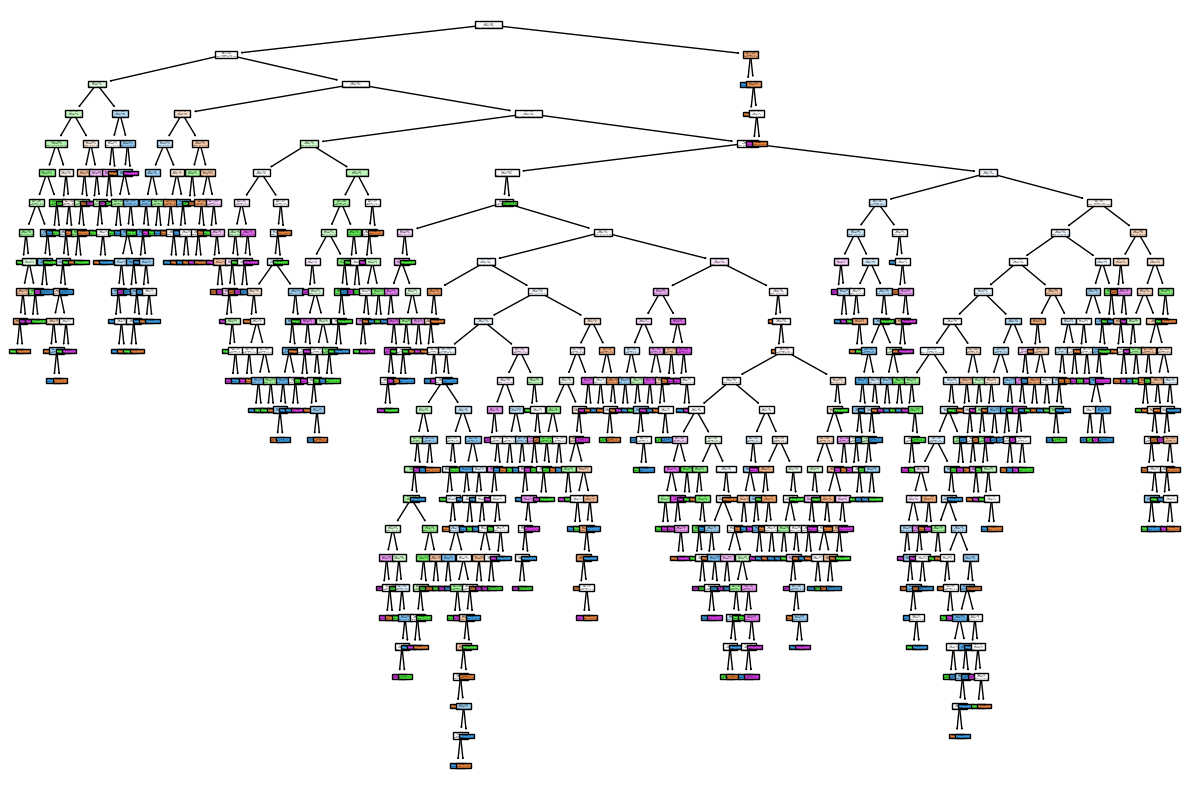

In [14]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(
    model,
    filled=True
)
plt.show()

In [15]:
model.fit(X_train, y_train)
joblib.dump(model, "decision_tree_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
